# ==============================
# PROJECT SETUP
# ==============================

In [2]:
#  ==========================================
#  Load required libraries
#  ==========================================
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display


In [3]:
# ==========================================
# Path and configuration setup
# ==========================================

# The notebook is inside notebooks/, so its parent folder is the repository root.
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Ensure the destination exists before downloading files.
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

NHANES_DATASETS = {
    "demographics": {
        "filename": "P_DEMO.XPT",
        "url": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.XPT",
    },
    "body_measures": {
        "filename": "P_BMX.XPT",
        "url": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BMX.XPT",
    },
    "blood_pressure": {
        "filename": "P_BPXO.XPT",
        "url": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPXO.XPT",
    },
    "bp_questionnaire": {
        "filename": "P_BPQ.XPT",
        "url": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPQ.XPT",
    },
    "diabetes_questionnaire": {
        "filename": "P_DIQ.XPT",
        "url": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DIQ.XPT",
    },
}

print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Number of datasets configured: {len(NHANES_DATASETS)}")

Raw data directory: /Users/iris/Documents/GitHub/Intelligent-Blood-Presure-Risk-Assessment/data/raw
Number of datasets configured: 5


# =========================
# DATA ACQUISATION
# =========================

In [4]:
# ==========================================
# Download datasets (if they don't exist)
# ==========================================

for dataset_name, dataset_info in NHANES_DATASETS.items():

    filename = dataset_info["filename"]
    url = dataset_info["url"]
    destination = RAW_DATA_DIR / filename

    if destination.exists():
        print(f"{filename} already exists. Skipping.")
        continue

    print(f"Downloading {filename}...")

    response = requests.get(url)
    response.raise_for_status()

    with open(destination, "wb") as file:
        file.write(response.content)

    print(f"Saved to {destination}")

print("\nAll datasets are ready.")

P_DEMO.XPT already exists. Skipping.
P_BMX.XPT already exists. Skipping.
P_BPXO.XPT already exists. Skipping.
P_BPQ.XPT already exists. Skipping.
P_DIQ.XPT already exists. Skipping.

All datasets are ready.


In [5]:
# ==========================================
# Load NHANES datasets
# ==========================================

demo_df = pd.read_sas(RAW_DATA_DIR / "P_DEMO.XPT")
bmx_df = pd.read_sas(RAW_DATA_DIR / "P_BMX.XPT")
bpxo_df = pd.read_sas(RAW_DATA_DIR / "P_BPXO.XPT")
bpq_df = pd.read_sas(RAW_DATA_DIR / "P_BPQ.XPT")
diq_df = pd.read_sas(RAW_DATA_DIR / "P_DIQ.XPT")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [6]:
#==========================================
# Check the columns of each dataset
#==========================================

datasets = {
    "Demographics": demo_df,
    "Body Measures": bmx_df,
    "Blood Pressure": bpxo_df,
    "BP Questionnaire": bpq_df,
    "Diabetes Questionnaire": diq_df,
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    df.info()
    print("\n")

Demographics
<class 'pandas.DataFrame'>
RangeIndex: 15560 entries, 0 to 15559
Data columns (total 29 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      15560 non-null  float64
 1   SDDSRVYR  15560 non-null  float64
 2   RIDSTATR  15560 non-null  float64
 3   RIAGENDR  15560 non-null  float64
 4   RIDAGEYR  15560 non-null  float64
 5   RIDAGEMN  987 non-null    float64
 6   RIDRETH1  15560 non-null  float64
 7   RIDRETH3  15560 non-null  float64
 8   RIDEXMON  14300 non-null  float64
 9   DMDBORN4  15560 non-null  float64
 10  DMDYRUSZ  3028 non-null   float64
 11  DMDEDUC2  9232 non-null   float64
 12  DMDMARTZ  9232 non-null   float64
 13  RIDEXPRG  1874 non-null   float64
 14  SIALANG   15560 non-null  float64
 15  SIAPROXY  15560 non-null  float64
 16  SIAINTRP  15560 non-null  float64
 17  FIALANG   14481 non-null  float64
 18  FIAPROXY  14481 non-null  float64
 19  FIAINTRP  14481 non-null  float64
 20  MIALANG   11000 non-null  

In [7]:
# ==========================================
# Check the columns of each dataset
# ==========================================

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Demographics
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDYRUSZ', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'WTINTPRP', 'WTMECPRP', 'SDMVPSU', 'SDMVSTRA', 'INDFMPIR']

Body Measures
['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP']

Blood Pressure
['SEQN', 'BPAOARM', 'BPAOCSZ', 'BPXOSY1', 'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3']

BP Questionnaire
['SEQN', 'BPQ020', 'BPQ030', 'BPD035', 'BPQ040A', 'BPQ050A', 'BPQ080', 'BPQ060', 'BPQ070', 'BPQ090D', 'BPQ100D']

Diabetes Questionnaire
['SEQN', 'DIQ010', 'DID040', 'DIQ160', 'DIQ180', 'DIQ050', 'DID060', 'DIQ060U', 'DIQ070', 'DIQ

# ===================================
# DATA PREPARATION
# ===================================

In [8]:
# ==========================================
# Create Version 1 datasets
# ==========================================

demo_v1_df = demo_df[
    [
        "SEQN",
        "RIDAGEYR",
        "RIAGENDR",
    ]
].copy()

bmx_v1_df = bmx_df[
    [
        "SEQN",
        "BMXBMI",
    ]
].copy()

bpxo_v1_df = bpxo_df[
    [
        "SEQN",
        "BPXOSY1",
        "BPXOSY2",
        "BPXOSY3",
        "BPXODI1",
        "BPXODI2",
        "BPXODI3",
    ]
].copy()

bpq_v1_df = bpq_df[
    [
        "SEQN",
        "BPQ050A",
    ]
].copy()

diq_v1_df = diq_df[
    [
        "SEQN",
        "DIQ010",
    ]
].copy()

print("Version 1 datasets created successfully!")

Version 1 datasets created successfully!


In [9]:
# ==========================================
# Check for duplicated SEQN values in Version 1 datasets
# ==========================================

v1_datasets = {
    "Demographics": demo_v1_df,
    "Body Measures": bmx_v1_df,
    "Blood Pressure": bpxo_v1_df,
    "BP Questionnaire": bpq_v1_df,
    "Diabetes Questionnaire": diq_v1_df,
}

for name, df in v1_datasets.items():
    duplicate_count = df["SEQN"].duplicated().sum()
    print(f"{name}: {duplicate_count} duplicated SEQN values")

Demographics: 0 duplicated SEQN values
Body Measures: 0 duplicated SEQN values
Blood Pressure: 0 duplicated SEQN values
BP Questionnaire: 0 duplicated SEQN values
Diabetes Questionnaire: 0 duplicated SEQN values


In [10]:
# ==========================================
# Merge Version 1 datasets
# ==========================================

model_v1_df = (
    demo_v1_df
    .merge(bmx_v1_df, on="SEQN", how="left", validate="one_to_one")
    .merge(bpxo_v1_df, on="SEQN", how="left", validate="one_to_one")
    .merge(bpq_v1_df, on="SEQN", how="left", validate="one_to_one")
    .merge(diq_v1_df, on="SEQN", how="left", validate="one_to_one")
)

print(model_v1_df.shape)
model_v1_df.head()

(15560, 12)


,SEQN,RIDAGEYR,RIAGENDR,BMXBMI,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPQ050A,DIQ010
0,109263.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
1,109264.0,13.0,2.0,17.6,109.0,109.0,106.0,67.0,68.0,66.0,NaN,2.0
2,109265.0,2.0,1.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
3,109266.0,29.0,2.0,37.8,99.0,99.0,99.0,56.0,55.0,52.0,NaN,2.0
4,109267.0,21.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [11]:
# ==========================================
# Checking Age Distribution
# ==========================================

model_v1_df[["RIDAGEYR", "BPXOSY1"]].groupby("RIDAGEYR").agg(
    Participants=("RIDAGEYR", "count"),
    BP_Measured=("BPXOSY1", lambda x: x.notna().sum())
)

,Participants,BP_Measured
RIDAGEYR,,
5.397605e-79,574,0
1.000000e+00,406,0
2.000000e+00,431,0
3.000000e+00,312,0
4.000000e+00,302,0
...,...,...
7.600000e+01,76,67
7.700000e+01,81,60
7.800000e+01,69,60


In [12]:
# ==========================================
# Check for infant (near 0 years old)
# ==========================================

tiny_age = model_v1_df["RIDAGEYR"] < 0.5

print("Affected rows:", tiny_age.sum())

model_v1_df.loc[
    tiny_age,
    ["SEQN", "RIDAGEYR", "BPXOSY1", "BPXOSY2", "BPXOSY3"]
].head(10)

Affected rows: 574


,SEQN,RIDAGEYR,BPXOSY1,BPXOSY2,BPXOSY3
9,109272.0,5.397605e-79,NaN,NaN,NaN
13,109276.0,5.397605e-79,NaN,NaN,NaN
18,109281.0,5.397605e-79,NaN,NaN,NaN
31,109294.0,5.397605e-79,NaN,NaN,NaN
51,109314.0,5.397605e-79,NaN,NaN,NaN
66,109329.0,5.397605e-79,NaN,NaN,NaN
82,109345.0,5.397605e-79,NaN,NaN,NaN
94,109357.0,5.397605e-79,NaN,NaN,NaN
123,109386.0,5.397605e-79,NaN,NaN,NaN
158,109421.0,5.397605e-79,NaN,NaN,NaN


In [13]:
# ==========================================
# Correcting infant age to 0 years old
# ==========================================

model_v1_df.loc[
    model_v1_df["RIDAGEYR"] < 0.5,
    "RIDAGEYR"
] = 0

sorted(model_v1_df["RIDAGEYR"].unique())[:10]

[np.float64(0.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0)]

In [14]:
# ==========================================
# Feature Engineering
# Create Average Blood Pressure Variables
# ==========================================

model_v1_df["Average_SBP"] = model_v1_df[
    ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
].mean(axis=1)

model_v1_df["Average_DBP"] = model_v1_df[
    ["BPXODI1", "BPXODI2", "BPXODI3"]
].mean(axis=1)

print("Average blood pressure variables created successfully.")

Average blood pressure variables created successfully.


In [15]:
# ==========================================
# Verify Engineered Features
# ==========================================

model_v1_df[
    [
        "BPXOSY1",
        "BPXOSY2",
        "BPXOSY3",
        "Average_SBP",
        "BPXODI1",
        "BPXODI2",
        "BPXODI3",
        "Average_DBP",
    ]
].head(10)

,BPXOSY1,BPXOSY2,BPXOSY3,Average_SBP,BPXODI1,BPXODI2,BPXODI3,Average_DBP
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109.0,109.0,106.0,108.000000,67.0,68.0,66.0,67.000000
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,99.0,99.0,99.0,99.000000,56.0,55.0,52.0,54.333333
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,123.0,124.0,127.0,124.666667,73.0,77.0,70.0,73.333333
8,102.0,108.0,111.0,107.000000,65.0,68.0,68.0,67.000000
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# =============================================
# EXPLORATORY DATA ANALYSIS (EDA)
# =============================================

In [16]:
# ==========================================
# EDA 1 - Target Variable Overview
# ==========================================

print(model_v1_df["Average_SBP"].describe())

print("\nMissing Average SBP:")
print(model_v1_df["Average_SBP"].isna().sum())

print("\nAvailable Average SBP:")
print(model_v1_df["Average_SBP"].notna().sum())

count    10353.000000
mean       119.810103
std         19.473950
min         72.333333
25%        106.000000
50%        116.666667
75%        130.000000
max        218.666667
Name: Average_SBP, dtype: float64

Missing Average SBP:
5207

Available Average SBP:
10353


In [17]:
# ==========================================
# 1.2 - Lowest and Highest Average SBP
# ==========================================

print("Lowest Average SBP")
display(model_v1_df.sort_values("Average_SBP").head(10))

print("Highest Average SBP")
display(model_v1_df.sort_values("Average_SBP", ascending=False).head(10))

Lowest Average SBP


,SEQN,RIDAGEYR,RIAGENDR,BMXBMI,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPQ050A,DIQ010,Average_SBP,Average_DBP
5053,114316.0,8.0,2.0,20.0,79.0,58.0,80.0,51.0,40.0,52.0,NaN,2.0,72.333333,47.666667
599,109862.0,41.0,2.0,35.9,76.0,80.0,73.0,47.0,44.0,45.0,NaN,2.0,76.333333,45.333333
806,110069.0,10.0,2.0,22.3,98.0,68.0,63.0,60.0,46.0,43.0,NaN,2.0,76.333333,49.666667
14294,123557.0,9.0,2.0,14.4,61.0,88.0,81.0,37.0,58.0,55.0,NaN,2.0,76.666667,50.000000
6778,116041.0,69.0,1.0,27.8,82.0,77.0,77.0,43.0,41.0,40.0,1.0,1.0,78.666667,41.333333
6298,115561.0,9.0,1.0,20.0,77.0,83.0,77.0,55.0,47.0,49.0,NaN,2.0,79.000000,50.333333
916,110179.0,9.0,2.0,19.2,80.0,78.0,79.0,44.0,43.0,43.0,NaN,2.0,79.000000,43.333333
14395,123658.0,11.0,2.0,20.4,77.0,83.0,78.0,46.0,47.0,46.0,NaN,2.0,79.333333,46.333333
12139,121402.0,9.0,2.0,18.0,77.0,84.0,77.0,45.0,51.0,49.0,NaN,2.0,79.333333,48.333333
4678,113941.0,66.0,2.0,61.6,66.0,86.0,87.0,37.0,66.0,62.0,1.0,1.0,79.666667,55.000000


Highest Average SBP


,SEQN,RIDAGEYR,RIAGENDR,BMXBMI,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPQ050A,DIQ010,Average_SBP,Average_DBP
3995,113258.0,53.0,1.0,33.1,219.0,222.0,215.0,100.0,101.0,102.0,1.0,2.0,218.666667,101.000000
13507,122770.0,80.0,2.0,45.0,224.0,211.0,217.0,86.0,90.0,92.0,1.0,1.0,217.333333,89.333333
5880,115143.0,79.0,1.0,35.2,220.0,214.0,NaN,151.0,119.0,NaN,NaN,2.0,217.000000,135.000000
3635,112898.0,62.0,2.0,41.0,213.0,218.0,220.0,94.0,97.0,85.0,1.0,2.0,217.000000,92.000000
7882,117145.0,67.0,2.0,NaN,225.0,208.0,NaN,71.0,76.0,NaN,1.0,2.0,216.500000,73.500000
1607,110870.0,78.0,1.0,27.4,217.0,215.0,210.0,77.0,66.0,59.0,1.0,1.0,214.000000,67.333333
2981,112244.0,66.0,2.0,NaN,200.0,222.0,220.0,137.0,141.0,135.0,1.0,1.0,214.000000,137.666667
8506,117769.0,63.0,1.0,32.9,220.0,212.0,208.0,113.0,116.0,96.0,2.0,2.0,213.333333,108.333333
5586,114849.0,66.0,2.0,58.7,203.0,215.0,213.0,92.0,96.0,97.0,2.0,2.0,210.333333,95.000000
12401,121664.0,40.0,1.0,28.5,205.0,219.0,204.0,141.0,136.0,128.0,2.0,2.0,209.333333,135.000000


In [18]:
# ==========================================
# 1.3 - Blood Pressure Measurement Variability
# ==========================================

model_v1_df["SBP_Range"] = model_v1_df[
    ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
].max(axis=1) - model_v1_df[
    ["BPXOSY1", "BPXOSY2", "BPXOSY3"]
].min(axis=1)

print(model_v1_df["SBP_Range"].describe())

count    10353.000000
mean         6.823143
std          5.417261
min          0.000000
25%          3.000000
50%          6.000000
75%          9.000000
max         91.000000
Name: SBP_Range, dtype: float64


In [19]:
# ==========================================
# EDA 2 - Blood Pressure Measurement Availability by Age
# ==========================================

bp_availability = (
    model_v1_df
    .groupby("RIDAGEYR")["Average_SBP"]
    .agg(
        Total="size",
        Available="count"
    )
    .assign(
        Missing=lambda df: df["Total"] - df["Available"],
        Availability_Percent=lambda df:
            (df["Available"] / df["Total"] * 100).round(1)
    )
)

bp_availability[bp_availability["Available"] > 0]

,Total,Available,Missing,Availability_Percent
RIDAGEYR,,,,
8.0,331,243,88,73.4
9.0,339,255,84,75.2
10.0,354,279,75,78.8
11.0,351,275,76,78.3
12.0,261,198,63,75.9
...,...,...,...,...
76.0,76,67,9,88.2
77.0,81,60,21,74.1
78.0,69,60,9,87.0


In [20]:
# ==========================================
# 2.1 - Create Version 1 Training Dataset
# ==========================================

model_training_df = model_v1_df.copy()

# Exclude participants younger than 8 years

model_training_df = model_training_df[
    model_training_df["RIDAGEYR"] >= 8
]

print("Rows:", len(model_training_df))
print("Minimum age:", model_training_df["RIDAGEYR"].min())

Rows: 12608
Minimum age: 8.0


In [21]:
# Remove observations without the target variable

model_training_df = model_training_df.dropna(
    subset=["Average_SBP"]
)

print("Rows:", len(model_training_df))
print("Missing Average_SBP:", model_training_df["Average_SBP"].isna().sum())

Rows: 10353
Missing Average_SBP: 0


## Training Dataset Construction

### Objective

Construct the dataset that will be used for machine learning by applying all approved inclusion and exclusion criteria.

### Applied Decisions

- DE006 – Exclude participants aged 0–7 years.
- DE007 – Remove observations with missing target values (`Average_SBP`).

### Notes

The original working dataset (`model_v1_df`) remains unchanged to preserve all NHANES observations for future exploratory analyses and feature engineering.

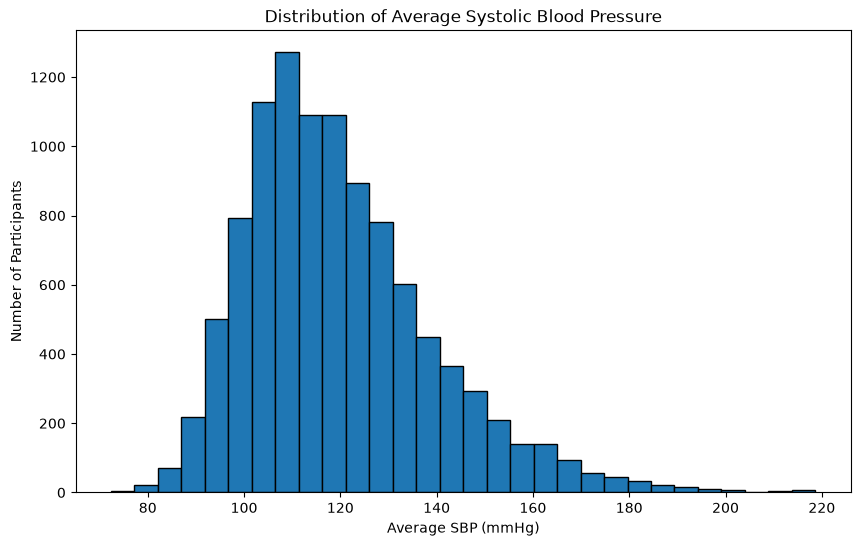

In [22]:
# Creating a histogram to visualize the distribution of Average Systolic Blood Pressure (SBP)

plt.figure(figsize=(10, 6))

plt.hist(
    model_training_df["Average_SBP"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Average Systolic Blood Pressure")
plt.xlabel("Average SBP (mmHg)")
plt.ylabel("Number of Participants")

plt.show()

Observations

* The distribution of Average_SBP is unimodal.
* The highest concentration of observations occurs around 110 mmHg.
* The distribution exhibits positive (right) skewness, with fewer participants having very high systolic blood pressure values.
* A small number of observations exceed 200 mmHg. These values are rare but remain within a clinically plausible range.

Interpretation

* The observed distribution is consistent with expectations for a population-based health survey.
* Right skewness reflects the relatively low prevalence of severe hypertension compared with normal blood pressure.
* No immediate evidence suggests erroneous target values requiring removal.
* Extreme systolic blood pressure values should be retained unless subsequent investigation identifies data quality issues.

/var/folders/9f/48g73zk123vbprx9zdt4gdz00000gn/T/ipykernel_95977/4239803420.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


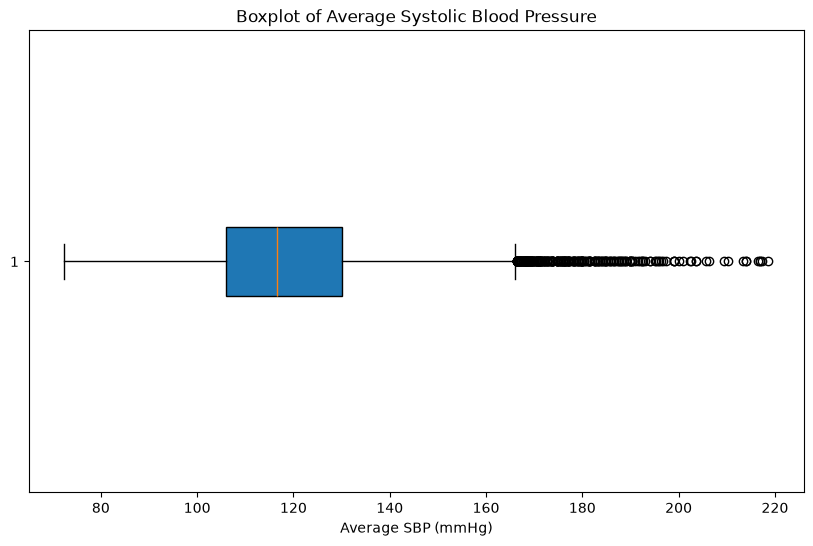

count    10353.000000
mean       119.810103
std         19.473950
min         72.333333
25%        106.000000
50%        116.666667
75%        130.000000
max        218.666667
Name: Average_SBP, dtype: float64

In [23]:
# Creating a boxplot to visualize the distribution of Average Systolic Blood Pressure (SBP)

plt.figure(figsize=(10, 6))

plt.boxplot(
    model_training_df["Average_SBP"],
    vert=False,
    patch_artist=True
)

plt.title("Boxplot of Average Systolic Blood Pressure")
plt.xlabel("Average SBP (mmHg)")

plt.show()

model_training_df["Average_SBP"].describe()

Observations

* The middle 50% of participants have an Average_SBP between 106 and 130 mmHg.
* The median Average_SBP is 116.67 mmHg.
* The mean (119.81 mmHg) is greater than the median, supporting a right-skewed distribution.
* The lower fence is 70 mmHg, and no observations fall below this threshold.
* The upper fence is 166 mmHg, with multiple observations beyond the upper whisker.

Interpretation

* The box plot confirms the histogram’s finding of a positively skewed distribution.
* Observations above the upper fence are statistically unusual but remain clinically plausible for patients with severe hypertension.
* There is currently no evidence that these observations represent data entry errors or measurement artifacts.

Project Impact

* No observations will be removed based solely on the box plot.
* Extreme SBP values will remain in the training dataset unless future investigation identifies data quality issues.

## EDA 5 – Age (RIDAGEYR)

### Objective

Understand the distribution and quality of the Age variable before evaluating its relationship with Average_SBP.

### Why this analysis?

Age is a clinically important predictor of blood pressure. Before using it in model development, we need to verify its completeness, distribution, and plausibility within the finalized training dataset.

### Method

Examine summary statistics and visualize the distribution of Age using the training dataset.

### Expected Outcome

- Confirm the age range of the training population.
- Verify the absence of missing values.
- Understand how participants are distributed across ages.

In [26]:
# 1. Summary statistics of Age
model_training_df["RIDAGEYR"].describe()

count    10353.000000
mean        41.040954
std         22.403663
min          8.000000
25%         19.000000
50%         41.000000
75%         61.000000
max         80.000000
Name: RIDAGEYR, dtype: float64

In [25]:
# 2. Missing values
model_training_df["RIDAGEYR"].isna().sum()

np.int64(0)

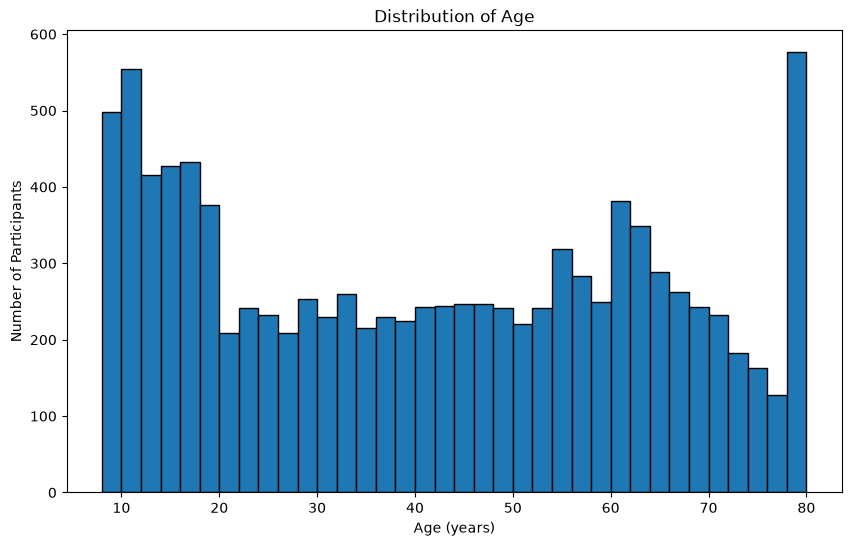

In [29]:
# 3. Histogram of Age Distribution
plt.figure(figsize=(10, 6))

plt.hist(
    model_training_df["RIDAGEYR"],
    bins=36,
    edgecolor="black"
)  
plt.title("Distribution of Age")
plt.xlabel("Age (years)")
plt.ylabel("Number of Participants")

plt.show()

In [28]:
age_counts = (
    model_training_df["RIDAGEYR"]
    .value_counts()
    .sort_index()
)

display(age_counts)

RIDAGEYR
8.0     243
9.0     255
10.0    279
11.0    275
12.0    198
       ... 
76.0     67
77.0     60
78.0     60
79.0     55
80.0    461
Name: count, Length: 73, dtype: int64

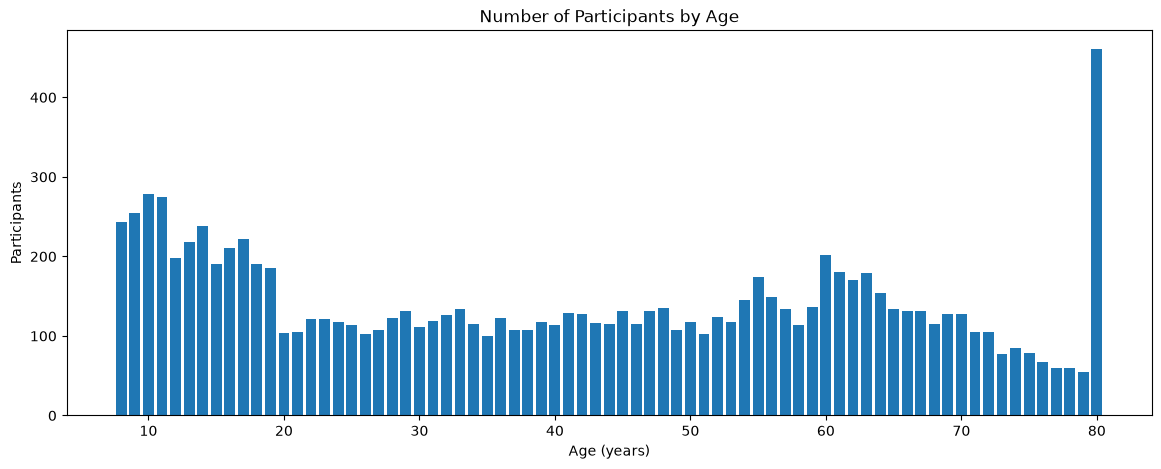

In [30]:
# 4. Bar chart of Age Distribution

age_counts = (
    model_training_df["RIDAGEYR"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,5))

plt.bar(
    age_counts.index,
    age_counts.values
)

plt.title("Number of Participants by Age")
plt.xlabel("Age (years)")
plt.ylabel("Participants")

plt.show()

# =======================================
# MODELING DATASET
# =======================================

# =======================================
# MODEL DEPLOYMENT
# =======================================

# =======================================
# CONCLUSION
# =======================================